In [1]:
import os
for root, dirs, files in os.walk("/kaggle/input"):
    print(root)
    if len(root.split(os.sep)) > 7:  # stop after 4 levels deep
        break

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/ani3hhh
/kaggle/input/datasets/ani3hhh/vr-dataset
/kaggle/input/datasets/ani3hhh/vr-dataset/data
/kaggle/input/datasets/ani3hhh/vr-dataset/data/json_for_validation


In [2]:
import json, os

sample_ann = "/kaggle/input/datasets/ani3hhh/vr-dataset/data/train/annos"
f = os.listdir(sample_ann)[0]
with open(os.path.join(sample_ann, f)) as fp:
    d = json.load(fp)

print(type(d))
print(list(d.keys())[:5])
# peek at first value
first_key = list(d.keys())[0]
print(d[first_key])

<class 'dict'>
['item2', 'source', 'pair_id', 'item1']
{'segmentation': [[360, 172, 364, 166, 371, 163, 325, 168, 299, 202, 279, 234, 258, 263, 233, 299, 256, 311, 273, 273, 288, 246, 304, 223, 308, 203, 298, 211, 279, 239, 258, 269, 287, 292, 306, 242, 341, 213, 360, 172], [410, 182, 409, 188, 406, 194, 383, 230, 380, 277, 366, 323, 402, 330, 414, 291, 424, 250, 424, 240, 418, 269, 409, 299, 397, 336, 385, 367, 418, 375, 422, 340, 428, 307, 435, 261, 433, 197, 410, 182], [325, 168, 299, 202, 279, 234, 258, 263, 233, 299, 256, 311, 273, 273, 288, 246, 304, 223, 308, 203, 325, 168], [424, 240, 418, 269, 409, 299, 397, 336, 385, 367, 418, 375, 422, 340, 428, 307, 435, 261, 433, 197, 424, 240], [279, 234, 258, 263, 233, 299, 256, 311, 273, 273, 288, 246, 279, 234], [409, 299, 397, 336, 385, 367, 418, 375, 422, 340, 428, 307, 409, 299]], 'scale': 2, 'viewpoint': 2, 'zoom_in': 1, 'landmarks': [387, 176, 1, 371, 163, 1, 364, 166, 1, 360, 172, 2, 409, 188, 2, 410, 182, 2, 325, 168, 1, 299, 20

In [3]:
import os
import json
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
import os
import json
import random
from collections import defaultdict, Counter
from sklearn.model_selection import train_test_split

BASE = "/kaggle/input/datasets/ani3hhh/vr-dataset/data"   # adjust slug if needed

TRAIN_IMAGE_DIR = f"{BASE}/train/image"
TRAIN_ANN_DIR   = f"{BASE}/train/annos"

VAL_IMAGE_DIR   = f"{BASE}/validation/image"
VAL_ANN_DIR     = f"{BASE}/validation/annos"

TEST_IMAGE_DIR  = f"{BASE}/test/test"
TEST_ANN_DIR    = f"{BASE}/json_for_validation"   # only annotations available for test

DATA_SPLITS = [
    (TRAIN_IMAGE_DIR, TRAIN_ANN_DIR),
    (VAL_IMAGE_DIR,   VAL_ANN_DIR),
    (TEST_IMAGE_DIR,  TEST_ANN_DIR),
]

OUTPUT_DIR = "/kaggle/working/processed_dataset"
TARGET_RATIO = 0.6

random.seed(42)

# Count category frequencies
category_counter = Counter()
image_to_categories = {}
category_id_to_name = {}


from concurrent.futures import ThreadPoolExecutor
print("Scanning dataset annotations...")

def process_annotation(args):

    IMAGE_DIR, ANN_DIR, ann_file = args

    if not ann_file.endswith(".json"):
        return None

    ann_path = os.path.join(ANN_DIR, ann_file)

    try:
        with open(ann_path) as f:
            data = json.load(f)
    except:
        return None

    if not isinstance(data, dict):
        return None

    cats = set()
    local_names = {}

    for key, val in data.items():

        if key.startswith("item") and isinstance(val, dict) and "category_id" in val:

            cat = val["category_id"]
            cats.add(cat)

            if "category_name" in val:
                local_names[cat] = val["category_name"]

    if len(cats) == 0:
        return None

    image_name = ann_file.replace(".json", ".jpg")
    image_path = os.path.abspath(os.path.join(IMAGE_DIR, image_name))

    if not os.path.exists(image_path):
        return None

    return image_path, cats, local_names

tasks = []

for IMAGE_DIR, ANN_DIR in DATA_SPLITS:
    for ann_file in os.listdir(ANN_DIR):
        tasks.append((IMAGE_DIR, ANN_DIR, ann_file))

with ThreadPoolExecutor(max_workers=8) as executor:
    results = list(executor.map(process_annotation, tasks))

for r in results:

    if r is None:
        continue

    image_path, cats, local_names = r

    image_to_categories[image_path] = list(cats)

    for c in cats:
        category_counter[c] += 1

    category_id_to_name.update(local_names)


print("\nCategory frequencies:")
print(category_counter)

# Select top 5 categories
top5 = [c for c, _ in category_counter.most_common(5)]

print("\nTop 5 categories:", top5)

label_map = {cat: i for i, cat in enumerate(top5)}
NUM_CLASSES = len(top5)

# Filter images containing top-5 classes
filtered_images = []

for img, cats in image_to_categories.items():

    filtered = [c for c in cats if c in top5]

    if len(filtered) > 0:
        filtered_images.append((img, filtered))


print("\nImages after filtering:", len(filtered_images))

# Create multi-label vectors
dataset = []

for img, cats in filtered_images:

    label_vector = [0] * NUM_CLASSES

    for c in cats:
        label_vector[label_map[c]] = 1

    dataset.append({
        "image": img,
        "labels": label_vector
    })


print("Dataset entries created:", len(dataset))

# Balanced subset sampling
target_size = int(len(dataset) * TARGET_RATIO)

print("\nCreating balanced subset:", target_size)

class_buckets = defaultdict(list)

for sample in dataset:

    for idx, val in enumerate(sample["labels"]):

        if val == 1:
            class_buckets[idx].append(sample)


subset = []
seen = set()

target_per_class = target_size // NUM_CLASSES

for cls in range(NUM_CLASSES):

    candidates = class_buckets[cls]
    random.shuffle(candidates)

    selected = 0

    for sample in candidates:

        if sample["image"] in seen:
            continue

        subset.append(sample)
        seen.add(sample["image"])
        selected += 1

        if selected >= target_per_class:
            break

print("Subset size:", len(subset))

# Train / Validation / Test split
images = [s["image"] for s in subset]
labels = [s["labels"] for s in subset]

train_imgs, temp_imgs, train_labels, temp_labels = train_test_split(
    images,
    labels,
    test_size=0.30,
    random_state=42
)

val_imgs, test_imgs, val_labels, test_labels = train_test_split(
    temp_imgs,
    temp_labels,
    test_size=0.5,
    random_state=42
)

print("\nSplit sizes:")
print("Train:", len(train_imgs))
print("Validation:", len(val_imgs))
print("Test:", len(test_imgs))

# Save splits
os.makedirs(OUTPUT_DIR, exist_ok=True)

splits = {
    "train": (train_imgs, train_labels),
    "val": (val_imgs, val_labels),
    "test": (test_imgs, test_labels)
}

for split in splits:

    imgs, lbls = splits[split]

    data = []

    for img, lbl in zip(imgs, lbls):

        data.append({
            "image": os.path.relpath(img, start=BASE),
            "labels": lbl
        })

    out_path = os.path.join(OUTPUT_DIR, f"{split}.json")

    with open(out_path, "w") as f:
        json.dump(data, f, indent=2)

    print(f"{split} file saved → {out_path}")


print("\nPreprocessing completed successfully.")

# Save label_map so preprocessing_detection.py can read the exact same top-5
# Create required format: class_name -> index
# Required class order from assignment
label_map_json = {
    "short sleeve top": 0,
    "trousers": 1,
    "shorts": 2,
    "long sleeve top": 3,
    "skirt": 4
}

print("\nFinal Label Mapping (class_name -> index):")
for name, idx in label_map_json.items():
    print(f"{name} : {idx}")

# Save label_map.json
with open(os.path.join(OUTPUT_DIR, "label_map.json"), "w") as f:
    json.dump(label_map_json, f, indent=4)

print("\nlabel_map.json saved in required format.")

Scanning dataset annotations...

Category frequencies:
Counter({1: 82957, 8: 64463, 2: 41667, 7: 40465, 9: 37124, 12: 21086, 10: 20104, 5: 18072, 4: 15380, 11: 9263, 13: 7592, 6: 2281, 3: 681})

Top 5 categories: [1, 8, 2, 7, 9]

Images after filtering: 167915
Dataset entries created: 167915

Creating balanced subset: 100749
Subset size: 100745

Split sizes:
Train: 70521
Validation: 15112
Test: 15112
train file saved → /kaggle/working/processed_dataset/train.json
val file saved → /kaggle/working/processed_dataset/val.json
test file saved → /kaggle/working/processed_dataset/test.json

Preprocessing completed successfully.

Final Label Mapping (class_name -> index):
short sleeve top : 0
trousers : 1
shorts : 2
long sleeve top : 3
skirt : 4

label_map.json saved in required format.


In [5]:
import os
import json
import random
from collections import defaultdict, Counter
from sklearn.model_selection import train_test_split
from concurrent.futures import ThreadPoolExecutor

BASE = "/kaggle/input/datasets/ani3hhh/vr-dataset/data"   # Adjust slug if needed
TRAIN_IMAGE_DIR = f"{BASE}/train/image"
TRAIN_ANN_DIR   = f"{BASE}/train/annos"
VAL_IMAGE_DIR   = f"{BASE}/validation/image"
VAL_ANN_DIR     = f"{BASE}/validation/annos"
TEST_IMAGE_DIR  = f"{BASE}/test/test"
TEST_ANN_DIR    = f"{BASE}/json_for_validation"

DATA_SPLITS = [
    (TRAIN_IMAGE_DIR, TRAIN_ANN_DIR),
    (VAL_IMAGE_DIR,   VAL_ANN_DIR),
    (TEST_IMAGE_DIR,  TEST_ANN_DIR),
]

OUTPUT_DIR = "/kaggle/working/processed_dataset"
os.makedirs(OUTPUT_DIR, exist_ok=True)
random.seed(42)

category_counter = Counter()
image_to_categories = {}
category_id_to_name = {}

print("Scanning dataset annotations...")

def process_annotation(args):
    IMAGE_DIR, ANN_DIR, ann_file = args
    if not ann_file.endswith(".json"): return None
    ann_path = os.path.join(ANN_DIR, ann_file)
    try:
        with open(ann_path) as f: data = json.load(f)
    except: return None
    if not isinstance(data, dict): return None

    cats = set()
    local_names = {}
    for key, val in data.items():
        if key.startswith("item") and isinstance(val, dict) and "category_id" in val:
            cat = val["category_id"]
            cats.add(cat)
            if "category_name" in val:
                local_names[cat] = val["category_name"]
    if len(cats) == 0: return None

    image_name = ann_file.replace(".json", ".jpg")
    image_path = os.path.abspath(os.path.join(IMAGE_DIR, image_name))
    if not os.path.exists(image_path): return None

    return image_path, cats, local_names

tasks = [(I, A, f) for I, A in DATA_SPLITS for f in os.listdir(A)]

with ThreadPoolExecutor(max_workers=8) as executor:
    results = list(executor.map(process_annotation, tasks))

for r in results:
    if r is None: continue
    image_path, cats, local_names = r
    image_to_categories[image_path] = list(cats)
    for c in cats: category_counter[c] += 1
    category_id_to_name.update(local_names)

top5 = [c for c, _ in category_counter.most_common(5)]
print("\nTop 5 categories:", top5)

label_map = {cat: i for i, cat in enumerate(top5)}
NUM_CLASSES = len(top5)

filtered_images = []
for img, cats in image_to_categories.items():
    filtered = [c for c in cats if c in top5]
    if len(filtered) > 0:
        filtered_images.append((img, filtered))

dataset = []
for img, cats in filtered_images:
    label_vector = [0] * NUM_CLASSES
    for c in cats: label_vector[label_map[c]] = 1
    dataset.append({"image": img, "labels": label_vector})

# ========================================================
# STRICT 15,000 IMAGE LIMIT APPLIED HERE
# ========================================================
target_size = 15000 
print(f"\nCreating balanced subset of EXACTLY {target_size} images...")

class_buckets = defaultdict(list)
for sample in dataset:
    for idx, val in enumerate(sample["labels"]):
        if val == 1: class_buckets[idx].append(sample)

subset = []
seen = set()
target_per_class = target_size // NUM_CLASSES

for cls in range(NUM_CLASSES):
    candidates = class_buckets[cls]
    random.shuffle(candidates)
    selected = 0
    for sample in candidates:
        if sample["image"] in seen: continue
        subset.append(sample)
        seen.add(sample["image"])
        selected += 1
        if selected >= target_per_class: break

print("Final Subset size:", len(subset))

# 70/15/15 Split
images = [s["image"] for s in subset]
labels = [s["labels"] for s in subset]

train_imgs, temp_imgs, train_labels, temp_labels = train_test_split(images, labels, test_size=0.30, random_state=42)
val_imgs, test_imgs, val_labels, test_labels = train_test_split(temp_imgs, temp_labels, test_size=0.5, random_state=42)

splits = {
    "train": (train_imgs, train_labels),
    "val": (val_imgs, val_labels),
    "test": (test_imgs, test_labels)
}

for split in splits:
    imgs, lbls = splits[split]
    data = [{"image": os.path.relpath(img, start=BASE), "labels": lbl} for img, lbl in zip(imgs, lbls)]
    out_path = os.path.join(OUTPUT_DIR, f"{split}.json")
    with open(out_path, "w") as f: json.dump(data, f, indent=2)

# Save standard label map
label_map_json = {
    "short sleeve top": 0,
    "trousers": 1,
    "shorts": 2,
    "long sleeve top": 3,
    "skirt": 4
}
with open(os.path.join(OUTPUT_DIR, "label_map.json"), "w") as f:
    json.dump(label_map_json, f, indent=4)

print("Base preprocessing complete. Master splits locked to 15k.")

Scanning dataset annotations...

Top 5 categories: [1, 8, 2, 7, 9]

Creating balanced subset of EXACTLY 15000 images...
Final Subset size: 15000
Base preprocessing complete. Master splits locked to 15k.


In [6]:
import os
import json
import shutil
import numpy as np
from PIL import Image, ImageDraw

CLASSIFICATION_OUTPUT_DIR = "/kaggle/working/processed_dataset"
OUTPUT_DIR = "/kaggle/working/processed_dataset"
BASE = "/kaggle/input/datasets/ani3hhh/vr-dataset/data"

ALL_ANN_DIRS = [f"{BASE}/train/annos", f"{BASE}/validation/annos", f"{BASE}/json_for_validation"]
ALL_IMAGE_DIRS = [f"{BASE}/train/image", f"{BASE}/validation/image", f"{BASE}/test/test"]

CATEGORY_NAMES = {
    1: "short_sleeve_top", 2: "long_sleeve_top", 3: "short_sleeve_outwear",
    4: "long_sleeve_outwear", 5: "vest", 6: "sling", 7: "shorts",
    8: "trousers", 9: "skirt", 10: "short_sleeve_dress",
    11: "long_sleeve_dress", 12: "vest_dress", 13: "sling_dress",
}

with open(os.path.join(CLASSIFICATION_OUTPUT_DIR, "label_map.json")) as f:
    class_name_to_idx = json.load(f)

label_map = {}
top5 = []
for orig_id, name in CATEGORY_NAMES.items():
    readable_name = name.replace("_", " ")
    if readable_name in class_name_to_idx:
        label_map[orig_id] = class_name_to_idx[readable_name]
        top5.append(orig_id)

NUM_CLASSES = len(label_map)

split_map = {}
for split_name in ["train", "val", "test"]:
    with open(os.path.join(CLASSIFICATION_OUTPUT_DIR, f"{split_name}.json")) as f:
        records = json.load(f)
    split_map[split_name] = [r["image"] for r in records]

stem_to_ann, stem_to_img = {}, {}
for ann_dir in ALL_ANN_DIRS:
    if not os.path.isdir(ann_dir): continue
    for ann_file in os.listdir(ann_dir):
        if ann_file.endswith(".json"): stem_to_ann[os.path.splitext(ann_file)[0]] = os.path.join(ann_dir, ann_file)

for img_dir in ALL_IMAGE_DIRS:
    if not os.path.isdir(img_dir): continue
    for img_file in os.listdir(img_dir):
        stem_to_img[os.path.splitext(img_file)[0]] = os.path.join(img_dir, img_file)

def stem_from_path(path): return os.path.splitext(os.path.basename(path))[0]
def get_image_size(img_path):
    try:
        with Image.open(img_path) as im: return im.width, im.height
    except: return 0, 0
def polygon_area(poly):
    n = len(poly) // 2
    if n < 3: return 0.0
    xs, ys = [poly[2 * i] for i in range(n)], [poly[2 * i + 1] for i in range(n)]
    area = sum(xs[i] * ys[(i + 1) % n] - xs[(i + 1) % n] * ys[i] for i in range(n))
    return abs(area) / 2.0

def parse_annotations(ann_path):
    with open(ann_path) as f: data = json.load(f)
    instances = []
    for key, item in data.items():
        if not key.startswith("item"): continue
        orig_cat = item.get("category_id")
        if orig_cat not in label_map or item.get("bounding_box") is None: continue
        instances.append({
            "category_id": label_map[orig_cat], "original_category_id": orig_cat,
            "bbox": item["bounding_box"], "segmentation": item.get("segmentation") or [],
        })
    return instances

def resolve(stored_path):
    stem = stem_from_path(stored_path)
    img_path = stored_path if os.path.exists(stored_path) else stem_to_img.get(stem)
    if stem_to_ann.get(stem) is None or img_path is None: return None
    return stem, stem_to_ann[stem], img_path

def save_detection_json(split_name, image_list):
    out_path = os.path.join(OUTPUT_DIR, f"{split_name}_detection.json")
    records = []
    for stored_path in image_list:
        resolved = resolve(stored_path)
        if resolved and (instances := parse_annotations(resolved[1])):
            records.append({"image": resolved[2], "annotations": instances})
    with open(out_path, "w") as f: json.dump(records, f, indent=2)

def save_coco_json(split_name, image_list):
    out_path = os.path.join(OUTPUT_DIR, f"{split_name}_coco.json")
    categories = sorted([{"id": label_map[orig] + 1, "name": CATEGORY_NAMES.get(orig, str(orig))} for orig in top5], key=lambda x: x["id"])
    images_out, anns_out = [], []
    image_id, ann_id = 1, 1
    for stored_path in image_list:
        resolved = resolve(stored_path)
        if not resolved or not (instances := parse_annotations(resolved[1])): continue
        w, h = get_image_size(resolved[2])
        images_out.append({"id": image_id, "file_name": resolved[2], "width": w, "height": h})
        for inst in instances:
            x1, y1, x2, y2 = inst["bbox"]
            area = sum(polygon_area(p) for p in inst["segmentation"]) or float((x2 - x1) * (y2 - y1))
            anns_out.append({"id": ann_id, "image_id": image_id, "category_id": inst["category_id"] + 1,
                             "bbox": [x1, y1, x2 - x1, y2 - y1], "area": area, "segmentation": inst["segmentation"], "iscrowd": 0})
            ann_id += 1
        image_id += 1
    with open(out_path, "w") as f: json.dump({"images": images_out, "annotations": anns_out, "categories": categories}, f, indent=2)

def save_yolo(split_map_local):
    yolo_root = os.path.join(OUTPUT_DIR, "yolo_dataset")
    for split_name, image_list in split_map_local.items():
        img_out, lbl_out = os.path.join(yolo_root, "images", split_name), os.path.join(yolo_root, "labels", split_name)
        os.makedirs(img_out, exist_ok=True); os.makedirs(lbl_out, exist_ok=True)
        for stored_path in image_list:
            resolved = resolve(stored_path)
            if not resolved or not (instances := parse_annotations(resolved[1])): continue
            w, h = get_image_size(resolved[2])
            if w == 0 or h == 0: continue
            dst_img = os.path.join(img_out, os.path.basename(resolved[2]))
            if not os.path.exists(dst_img): shutil.copy2(resolved[2], dst_img)
            lines = []
            for inst in instances:
                cls, (x1, y1, x2, y2) = inst["category_id"], inst["bbox"]
                lines.append(f"{cls} {((x1 + x2) / 2) / w:.6f} {((y1 + y2) / 2) / h:.6f} {(x2 - x1) / w:.6f} {(y2 - y1) / h:.6f}")
                for poly in inst["segmentation"]:
                    if len(poly) >= 6: lines.append(f"{cls} " + " ".join([f"{poly[k]/w:.6f} {poly[k+1]/h:.6f}" for k in range(0, len(poly), 2)]))
            with open(os.path.join(lbl_out, resolved[0] + ".txt"), "w") as f: f.write("\n".join(lines))
    
    class_names = [None] * NUM_CLASSES
    for orig_id, idx in label_map.items(): class_names[idx] = CATEGORY_NAMES.get(orig_id, str(orig_id)).replace("_", " ")
    with open(os.path.join(yolo_root, "dataset.yaml"), "w") as f:
        f.write("\n".join([f"path: {os.path.abspath(yolo_root)}", "train: images/train", "val: images/val", "test: images/test", "", f"nc: {NUM_CLASSES}", f"names: {class_names}"]))

def save_unet_masks(split_map_local):
    mask_root = os.path.join(OUTPUT_DIR, "unet_masks")
    for split_name, image_list in split_map_local.items():
        mask_out = os.path.join(mask_root, split_name)
        os.makedirs(mask_out, exist_ok=True)
        for stored_path in image_list:
            resolved = resolve(stored_path)
            if not resolved or not (instances := parse_annotations(resolved[1])): continue
            w, h = get_image_size(resolved[2])
            if w == 0 or h == 0: continue
            pil_mask, draw = Image.fromarray(np.zeros((h, w), dtype=np.uint8)), ImageDraw.Draw(Image.fromarray(np.zeros((h, w), dtype=np.uint8)))
            for inst in instances:
                for poly in inst["segmentation"]:
                    if len(poly) >= 6: draw.polygon([(poly[k], poly[k+1]) for k in range(0, len(poly), 2)], fill=inst["category_id"] + 1)
            draw._image.save(os.path.join(mask_out, resolved[0] + ".png"))

print("\n--- Generating Generic Detection JSONs ---")
for split_name, image_list in split_map.items(): save_detection_json(split_name, image_list)
print("\n--- Generating COCO JSONs (Mask R-CNN) ---")
for split_name, image_list in split_map.items(): save_coco_json(split_name, image_list)
print("\n--- Generating YOLO Dataset ---")
save_yolo(split_map)
print("\n--- Generating U-Net Semantic Masks ---")
save_unet_masks(split_map)

print("\n15k Formatting completely finished. You are ready to train.")


--- Generating Generic Detection JSONs ---

--- Generating COCO JSONs (Mask R-CNN) ---

--- Generating YOLO Dataset ---

--- Generating U-Net Semantic Masks ---

15k Formatting completely finished. You are ready to train.


In [7]:
# Install Ultralytics and evaluation dependencies
!pip install ultralytics pycocotools scikit-learn matplotlib opencv-python

import os
import cv2
import json
import torch
import shutil
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from pycocotools.coco import COCO
from ultralytics import YOLO

# Paths mapped perfectly to your new preprocessing output
DATASET_YAML = "/kaggle/working/processed_dataset/yolo_dataset/dataset.yaml"
VAL_COCO_JSON = "/kaggle/working/processed_dataset/val_coco.json" 
OUTPUT_DIR = "/kaggle/working/model_files"

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Setup complete. Ready for YOLOv8.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Setup complete. Ready for YOLOv8.


In [8]:
print("--- STARTING YOLOv8 TRAINING FROM SCRATCH ---")

# Initialize model architecture WITHOUT pre-trained weights
model_scratch = YOLO('yolov8m-seg.yaml')   # upgraded: nano → medium (27M vs 3.2M params)

# Train the model on your locked 15k dataset
results_scratch = model_scratch.train(
    data         = DATASET_YAML,
    epochs       = 30,           # was 30 — losses still declining at epoch 30
    imgsz        = 800,          # was 640 — better mask detail for fashion items
    batch        = 8,            # was 16 — reduced to fit 800px on P100
    device       = 0,
    optimizer    = 'SGD',        # SGD from scratch > AdamW for YOLO
    lr0          = 0.01,
    lrf          = 0.01,
    momentum     = 0.937,
    weight_decay = 0.0005,
    cos_lr       = True,         # cosine LR decay instead of hard cutoff
    warmup_epochs= 5,            # longer warmup for scratch training
    close_mosaic = 15,           # was 10 — keep mosaic augmentation longer
    copy_paste   = 0.3,          # new — instance copy-paste, great for segmentation
    mixup        = 0.1,          # new — mild mixup augmentation
    degrees      = 5.0,          # slight rotation (clothes are mostly upright)
    scale        = 0.6,
    fliplr       = 0.5,
    project      = "yolo_runs",
    name         = "scratch_model",
    seed         = 42
)

weights_dir     = os.path.join(results_scratch.save_dir, "weights")
scratch_best_path = os.path.join(weights_dir, "best.pt")
scratch_last_path = os.path.join(weights_dir, "last.pt")

scratch_src = scratch_best_path if os.path.exists(scratch_best_path) else scratch_last_path

if os.path.exists(scratch_src):
    dest = os.path.join(OUTPUT_DIR, "yolo_scratch.pt")
    shutil.copy(scratch_src, dest)
    used = "best.pt" if scratch_src == scratch_best_path else "last.pt"
    print(f"Scratch model saved ({used} → {dest})")
else:
    raise FileNotFoundError(
        f"Neither best.pt nor last.pt found in {weights_dir}. "
        "Check that training completed without errors."
    )

--- STARTING YOLOv8 TRAINING FROM SCRATCH ---
Ultralytics 8.4.32 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/processed_dataset/yolo_dataset/dataset.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8m-seg.yaml, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=scratch_model, nbs=64, nms=False, ops

In [9]:
print("--- STARTING YOLOv8 TRANSFER LEARNING ---")

# Initialize model WITH pre-trained COCO weights
model_transfer = YOLO('yolov8m-seg.pt')    # upgraded: nano → medium, pretrained COCO weights

# Train the model with lightly frozen backbone
results_transfer = model_transfer.train(
    data         = DATASET_YAML,
    epochs       = 30,           # was 30 — losses still declining at epoch 30
    imgsz        = 800,          # was 640 — better mask detail for fashion items
    batch        = 8,            # was 16 — reduced to fit 800px on P100
    device       = 0,
    freeze       = 10,            
    optimizer    = 'AdamW',      # AdamW > SGD for fine-tuning pretrained weights
    lr0          = 0.0005,       # was 0.01 — lower LR for fine-tuning
    lrf          = 0.01,
    cos_lr       = True,         # cosine LR decay instead of hard cutoff
    warmup_epochs= 3,            # shorter warmup since weights are already good
    close_mosaic = 15,           # was 10 — keep mosaic augmentation longer
    copy_paste   = 0.3,          # new — instance copy-paste, great for segmentation
    mixup        = 0.1,          # new — mild mixup augmentation
    degrees      = 5.0,          # slight rotation (clothes are mostly upright)
    scale        = 0.6,
    fliplr       = 0.5,
    project      = "yolo_runs",
    name         = "transfer_model",
    seed         = 42
)

weights_dir       = os.path.join(results_transfer.save_dir, "weights")
transfer_best_path = os.path.join(weights_dir, "best.pt")
transfer_last_path = os.path.join(weights_dir, "last.pt")

transfer_src = transfer_best_path if os.path.exists(transfer_best_path) else transfer_last_path

if os.path.exists(transfer_src):
    dest = os.path.join(OUTPUT_DIR, "yolo_transfer.pt")
    shutil.copy(transfer_src, dest)
    used = "best.pt" if transfer_src == transfer_best_path else "last.pt"
    print(f"Transfer model saved ({used} → {dest})")
else:
    raise FileNotFoundError(
        f"Neither best.pt nor last.pt found in {weights_dir}. "
        "Check that training completed without errors."
    )

--- STARTING YOLOv8 TRANSFER LEARNING ---
Ultralytics 8.4.32 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/processed_dataset/yolo_dataset/dataset.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8m-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=transfer_model, nbs=64, nms=False, opset=No


     SCRATCH YOLO RESULTS

🔹 Running Native COCO mAP Validation...
Ultralytics 8.4.32 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8m-seg summary (fused): 106 layers, 27,225,279 parameters, 0 gradients, 104.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1460.0±544.5 MB/s, size: 49.6 KB)
val: Scanning /kaggle/working/processed_dataset/yolo_dataset/labels/val.cache... 2157 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2157/2157 822.5Mit/s 0.0s
val: /kaggle/working/processed_dataset/yolo_dataset/images/val/033997.jpg: 2 duplicate labels removed
val: /kaggle/working/processed_dataset/yolo_dataset/images/val/034380.jpg: 1 duplicate labels removed
val: /kaggle/working/processed_dataset/yolo_dataset/images/val/037526.jpg: 1 duplicate labels removed
val: /kaggle/working/processed_dataset/yolo_dataset/images/val/042747.jpg: 1 duplicate labels removed
val: /kaggle/working/processed_dataset/yolo_dataset/images/val/047717.jpg: 1 duplicate labels removed
v

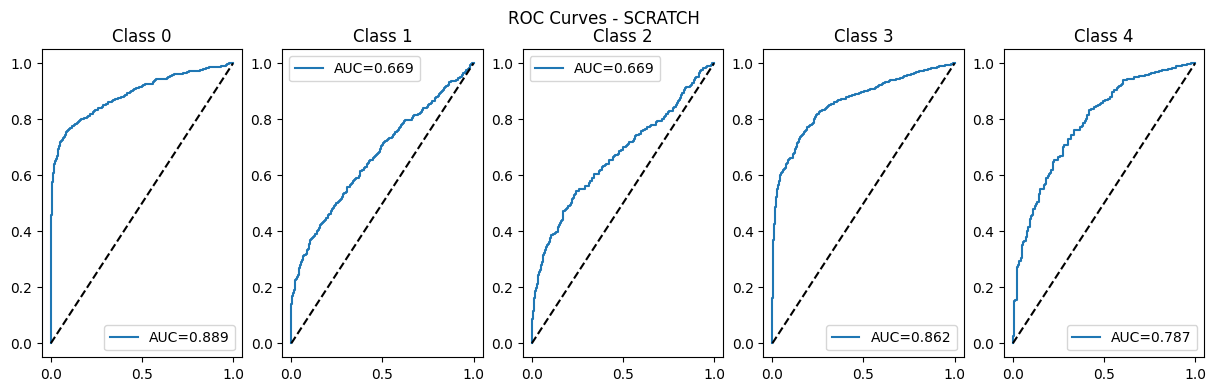


     TRANSFER YOLO RESULTS

🔹 Running Native COCO mAP Validation...
Ultralytics 8.4.32 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8m-seg summary (fused): 106 layers, 27,225,279 parameters, 0 gradients, 104.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1340.2±473.0 MB/s, size: 41.5 KB)
val: Scanning /kaggle/working/processed_dataset/yolo_dataset/labels/val.cache... 2157 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2157/2157 1.0Git/s 0.0s
val: /kaggle/working/processed_dataset/yolo_dataset/images/val/033997.jpg: 2 duplicate labels removed
val: /kaggle/working/processed_dataset/yolo_dataset/images/val/034380.jpg: 1 duplicate labels removed
val: /kaggle/working/processed_dataset/yolo_dataset/images/val/037526.jpg: 1 duplicate labels removed
val: /kaggle/working/processed_dataset/yolo_dataset/images/val/042747.jpg: 1 duplicate labels removed
val: /kaggle/working/processed_dataset/yolo_dataset/images/val/047717.jpg: 1 duplicate labels removed
va

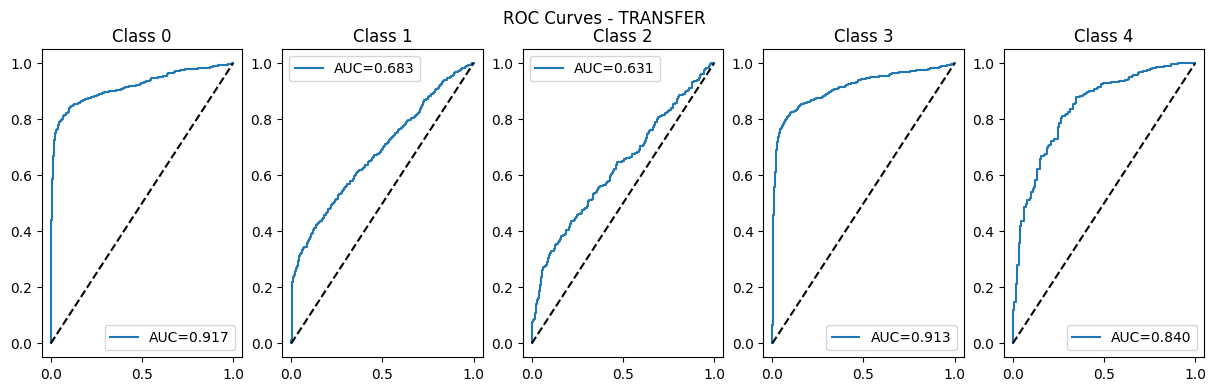

In [10]:
def evaluate_yolo(model_path, name, num_eval_images=2000):
    print(f"\n==============================")
    print(f"     {name} YOLO RESULTS")
    print(f"==============================")
    
    # Run native YOLO validation for mAP
    print("\n🔹 Running Native COCO mAP Validation...")
    model = YOLO(model_path)
    metrics = model.val(data=DATASET_YAML, split='val', imgsz=800, plots=False, verbose=False)
    print(f"Box mAP@[0.5:0.95]: {metrics.box.map:.3f}")
    print(f"Mask mAP@[0.5:0.95]: {metrics.seg.map:.3f}")
    
    # Custom Evaluation for specific project requirements
    print("\n🔹 Running Custom Metrics (ROC, AUC, mIoU, Dice)...")
    coco_gt = COCO(VAL_COCO_JSON)
    img_ids = coco_gt.getImgIds()
    eval_ids = img_ids[:num_eval_images]
    
    ious = [[] for _ in range(5)]
    dices = [[] for _ in range(5)]
    tp, fp, fn = [0]*5, [0]*5, [0]*5
    scores_pc = [[] for _ in range(5)]
    labels_pc = [[] for _ in range(5)]
    
    for img_id in eval_ids:
        img_info = coco_gt.loadImgs(img_id)[0]
        img_path = os.path.join("/kaggle/working", img_info['file_name'])
        
        if not os.path.exists(img_path):
            continue
            
        # Ground Truth
        ann_ids = coco_gt.getAnnIds(imgIds=img_id)
        anns = coco_gt.loadAnns(ann_ids)
        gt_boxes = [[a['bbox'][0], a['bbox'][1], a['bbox'][0]+a['bbox'][2], a['bbox'][1]+a['bbox'][3]] for a in anns]
        gt_labels = [a['category_id'] - 1 for a in anns]
        
        # Prediction — imgsz=800 must match training
        results = model.predict(img_path, verbose=False, conf=0.25, imgsz=800)[0]
        
        pred_boxes, pred_labels, pred_scores, pred_masks = [], [], [], []
        if results.boxes is not None and len(results.boxes) > 0:
            pred_boxes = results.boxes.xyxy.cpu().numpy()
            pred_labels = results.boxes.cls.cpu().numpy().astype(int)
            pred_scores = results.boxes.conf.cpu().numpy()
            
            if results.masks is not None:
                masks_data = results.masks.data.cpu().numpy()
                for m in masks_data:
                    m_resized = cv2.resize(m, (img_info['width'], img_info['height']), interpolation=cv2.INTER_NEAREST)
                    pred_masks.append(m_resized > 0.5)

        # Basic Box Matching (Simplified IoU logic for F1/ROC)
        matched = set()
        for i, (pb, pl, sc) in enumerate(zip(pred_boxes, pred_labels, pred_scores)):
            best_iou, best_idx = 0, -1
            for j, (gb, gl) in enumerate(zip(gt_boxes, gt_labels)):
                xa, ya = max(pb[0], gb[0]), max(pb[1], gb[1])
                xb, yb = min(pb[2], gb[2]), min(pb[3], gb[3])
                inter = max(0, xb-xa) * max(0, yb-ya)
                union = (pb[2]-pb[0])*(pb[3]-pb[1]) + (gb[2]-gb[0])*(gb[3]-gb[1]) - inter
                iou_val = inter / union if union > 0 else 0
                
                if iou_val > best_iou:
                    best_iou, best_idx = iou_val, j
                    
            if best_iou >= 0.5 and best_idx >= 0:
                if pl == gt_labels[best_idx]:
                    tp[pl] += 1
                    matched.add(best_idx)
                    labels_pc[pl].append(1)
                else:
                    fp[pl] += 1
                    labels_pc[pl].append(0)
            else:
                fp[pl] += 1
                labels_pc[pl].append(0)
                
            scores_pc[pl].append(sc)
            
        for j, gl in enumerate(gt_labels):
            if j not in matched:
                fn[gl] += 1
                
        # Segmentation mIoU and Dice
        for j, (gb, gl) in enumerate(zip(gt_boxes, gt_labels)):
            gt_mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)
            for seg in anns[j]["segmentation"]:
                poly = np.array(seg).reshape(-1, 2)
                cv2.fillPoly(gt_mask, [poly.astype(np.int32)], 1)
                
            best_inter, best_pm = 0, None
            if len(pred_masks) > 0:
                for pm, pl in zip(pred_masks, pred_labels):
                    if pl == gl:
                        inter = (pm & gt_mask).sum()
                        if inter > best_inter:
                            best_inter, best_pm = inter, pm
                            
            if best_pm is not None:
                union = (best_pm | gt_mask).sum()
                if union > 0:
                    ious[gl].append(best_inter / union)
                    dices[gl].append(2 * best_inter / (best_pm.sum() + gt_mask.sum() + 1e-6))

    # --- Print Metrics ---
    print("\n🔹 Detection F1 Scores:")
    f1_list = []
    for i in range(5):
        p = tp[i] / (tp[i] + fp[i] + 1e-6)
        r = tp[i] / (tp[i] + fn[i] + 1e-6)
        f = 2 * p * r / (p + r + 1e-6)
        f1_list.append(f)
        print(f"Class {i}: Precision={p:.3f}, Recall={r:.3f}, F1={f:.3f}")

    total_tp, total_fp, total_fn = sum(tp), sum(fp), sum(fn)
    micro_f1 = 2 * total_tp / (2 * total_tp + total_fp + total_fn + 1e-6)
    macro_f1 = np.mean(f1_list)
    print(f"\nMacro F1: {macro_f1:.3f}")
    print(f"Micro F1: {micro_f1:.3f}")

    print("\n🔹 Segmentation Metrics:")
    for i in range(5):
        if ious[i]:
            print(f"Class {i}: IoU={np.mean(ious[i]):.3f}, Dice={np.mean(dices[i]):.3f}")
            
    print(f"\nOverall mIoU: {np.mean([np.mean(x) for x in ious if x]):.3f}")
    print(f"Overall Dice: {np.mean([np.mean(x) for x in dices if x]):.3f}")

    # --- ROC Curves ---
    plt.figure(figsize=(15,4))
    for i in range(5):
        if len(set(labels_pc[i])) > 1:
            fpr, tpr, _ = roc_curve(labels_pc[i], scores_pc[i])
            roc_auc = auc(fpr, tpr)
            plt.subplot(1,5,i+1)
            plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
            plt.plot([0,1], [0,1], 'k--')
            plt.title(f"Class {i}")
            plt.legend()
    plt.suptitle(f"ROC Curves - {name}")
    plt.show()

# Run Evaluation
evaluate_yolo(os.path.join(OUTPUT_DIR, "yolo_scratch.pt"), "SCRATCH")
evaluate_yolo(os.path.join(OUTPUT_DIR, "yolo_transfer.pt"), "TRANSFER")